# 00 - PanTS Metadata Exploration
**AI-Based Pancreatic Cancer Prediction Using Deep Learning** - Phase-II Review 1

PanTS (Li et al., NeurIPS 2025) is the project's external-validation dataset: the full release is 36,390 CT scans across 145 centres and roughly 300 GB. We do **not** train on it - the image data is staged separately for Review 2 and used to test generalisation.

The **metadata file (1.3 MB)** ships with the Hugging Face mirror and already answers the questions that motivate this project: how many pancreatic tumors are under 2 cm, which contrast phases are present, and how cases are spread across hospitals.

Runs on CPU in under a minute. Works in Colab or locally.

In [1]:
%pip install -q pandas openpyxl matplotlib huggingface_hub

import os, re, json, shutil
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# Resolve the repo root so this works the same in Colab (cwd = repo) and in
# Jupyter/VS Code (cwd = notebooks/). Without this, results land in
# notebooks/results/ and never reach the folder the deck cites.
ROOT = os.getcwd()
while not os.path.exists(os.path.join(ROOT, 'requirements.txt')) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)

DATA_DIR = os.path.join(ROOT, 'data', 'PanTS')
RESULTS  = os.path.join(ROOT, 'results', 'review1')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS, exist_ok=True)
print('repo root:', ROOT)

XLSX = os.path.join(DATA_DIR, 'metadata.xlsx')
if not os.path.exists(XLSX):
    from huggingface_hub import hf_hub_download
    cached = hf_hub_download(repo_id='BodyMaps/PanTSMini',
                             filename='metadata.xlsx', repo_type='dataset')
    shutil.copy(cached, XLSX)

df = pd.read_excel(XLSX)
df.columns = [c.strip() for c in df.columns]
print('rows:', len(df), '| columns:', len(df.columns))
df.columns.tolist()

Note: you may need to restart the kernel to use updated packages.


repo root: C:\dev\capstone


rows: 9901 | columns: 15


['PanTS ID',
 'shape',
 'spacing',
 'ct phase',
 'sex',
 'age',
 'manufacturer',
 'manufacturer model',
 'study type',
 'site',
 'site detail',
 'site nationality',
 'study year',
 'tumor?',
 'structured report']

The 15 column names printed above are the real ones. Note what is **not** there: no tumor size, no diameter, no lesion column. That is the first finding of this notebook, and it decides how the rest of it works.

In [2]:
df.head(3)

,PanTS ID,shape,spacing,ct phase,sex,age,manufacturer,manufacturer model,study type,site,site detail,site nationality,study year,tumor?,structured report
0,PanTS_00000001,"(512, 333, 200)","(0.625, 0.625, 0.8)",Non-contrast,F,66.0,SIEMENS,Sensation 16,ct colonography,15 Sites,Mayo Clinic Arizona; Brown University Center f...,US,2000,0,FINDINGS: _x000D_\nSpleen: _x000D_\nNormal siz...
1,PanTS_00000002,"(275, 198, 180)","(1.5, 1.5, 1.5)",Non-contrast,F,60.0,SIEMENS,somatom definition edge,ct thorax-abdomen-pelvis,I,University Hospital Basel (10 Sites: A; B; C; ...,CH,2012; 2016; 2020,0,FINDINGS: _x000D_\nSpleen: _x000D_\nNormal siz...
2,PanTS_00000003,"(495, 349, 40)","(0.818359, 0.818359, 7.5)",Venous,NaN,NaN,NaN,NaN,NaN,1 Site,Memorial Sloan Kettering Cancer Center,US,NaN,1,FINDINGS: _x000D_\nSpleen: _x000D_\nNormal siz...


In [3]:
# ---- real column names, read off the file above (not guessed) ----
COL_ID, COL_PHASE, COL_SITE = 'PanTS ID', 'ct phase', 'site'
COL_TUMOR, COL_REPORT       = 'tumor?', 'structured report'

# metadata.xlsx has NO tumor-size column. Lesion measurements are inside the
# free-text radiology report, formatted like:
#     Pancreas lesion 1:
#     Location: pancreas head.
#     Size: 2.4 x 1.4 cm (image 14). Volume: 5.3 cc.
#     Enhancement relative to pancreas: Isoattenuating.
# Excel stores the report's newlines as the literal escape "_x000D_".

LESION_SPLIT = re.compile(r'Pancreas lesion\s+(\d+)\s*:', re.I)
SIZE         = re.compile(r'Size:\s*([\d.]+)\s*x\s*([\d.]+)(?:\s*x\s*([\d.]+))?\s*(cm|mm)', re.I)
LOCATION     = re.compile(r'Location:\s*([^.\n]+)', re.I)
ENHANCEMENT  = re.compile(r'Enhancement relative to pancreas:\s*([A-Za-z\-]+)', re.I)


def parse_lesions(report):
    """Return one dict per measured pancreas lesion; [] if the report has none."""
    if not isinstance(report, str):
        return []
    text  = report.replace('_x000D_', '\n')
    parts = LESION_SPLIT.split(text)
    if len(parts) < 3:
        return []
    out = []
    for idx, body in zip(parts[1::2], parts[2::2]):
        body = re.split(r'\n\s*(?:Kidney|Liver|Spleen|IMPRESSION)\s*:', body)[0]
        m = SIZE.search(body)
        if not m:
            continue
        dims = [float(d) for d in m.group(1, 2, 3) if d is not None]
        if m.group(4).lower() == 'mm':
            dims = [d / 10.0 for d in dims]
        loc, enh = LOCATION.search(body), ENHANCEMENT.search(body)
        out.append({'lesion': int(idx),
                    'long_axis_cm':  max(dims),
                    'short_axis_cm': min(dims),
                    'location':    loc.group(1).strip().lower() if loc else None,
                    'enhancement': enh.group(1).strip().lower() if enh else None})
    return out


rows = []
for _, case in df.iterrows():
    for lesion in parse_lesions(case[COL_REPORT]):
        rows.append({COL_ID: case[COL_ID], 'tumor': case[COL_TUMOR], **lesion})
lesions = pd.DataFrame(rows)

# A "pancreas lesion" is NOT the same as the tumor? flag: most measured lesions
# sit in cases flagged tumor?=0 and are benign. Pooling them would inflate the
# cohort and skew the size distribution, so keep the two populations apart.
tumor_lesions  = lesions[lesions['tumor'] == 1]
benign_lesions = lesions[lesions['tumor'] == 0]

n_tumor_cases = int((df[COL_TUMOR] == 1).sum())
coverage_pct  = round(100 * tumor_lesions[COL_ID].nunique() / n_tumor_cases, 1)

print(f'cases                     : {len(df)}')
print(f'flagged with tumor        : {n_tumor_cases} ({100 * n_tumor_cases / len(df):.1f}%)')
print(f'tumor lesions measured    : {len(tumor_lesions)} in '
      f'{tumor_lesions[COL_ID].nunique()} cases ({coverage_pct}% of tumor cases)')
print(f'benign lesions (tumor?=0) : {len(benign_lesions)}  <- kept separate')
lesions.head()

cases                     : 9901
flagged with tumor        : 1077 (10.9%)
tumor lesions measured    : 379 in 314 cases (29.2% of tumor cases)
benign lesions (tumor?=0) : 821  <- kept separate


,PanTS ID,tumor,lesion,long_axis_cm,short_axis_cm,location,enhancement
0,PanTS_00000003,1,1,2.4,1.4,pancreas head,isoattenuating
1,PanTS_00000026,1,1,4.6,2.9,pancreas body/tail,hyperattenuating
2,PanTS_00000029,1,1,2.0,1.8,pancreas body,isoattenuating
3,PanTS_00000031,1,1,1.6,1.1,pancreas tail,hypoattenuating
4,PanTS_00000031,1,2,1.6,1.0,pancreas head,hyperattenuating


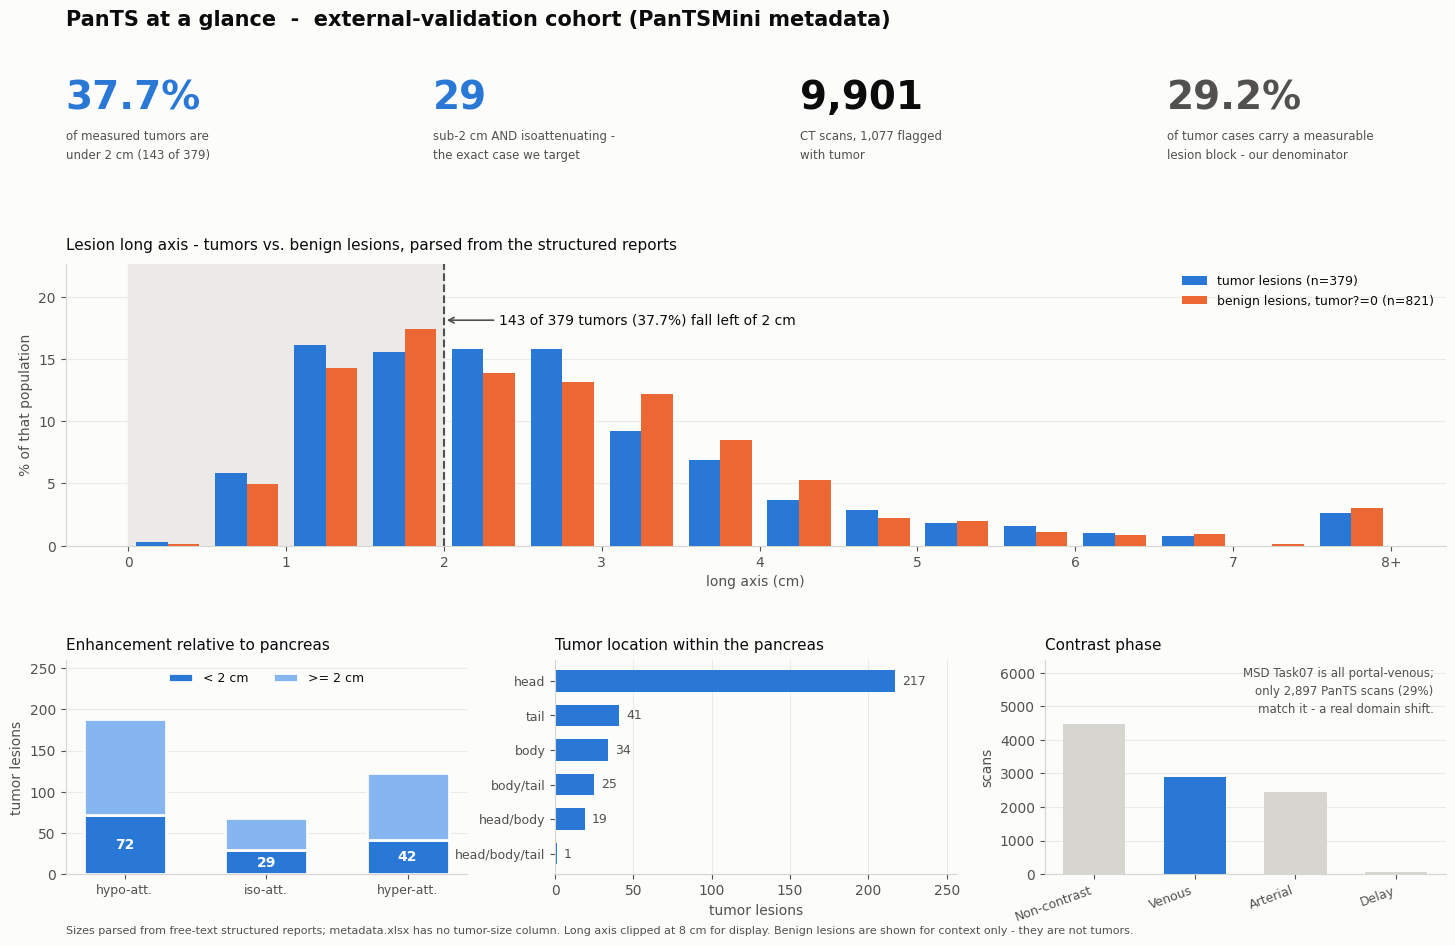

In [4]:
# ============================================================================
# "PanTS at a glance" - the Review 1 figure (deck slide 11)
# Palette: validated categorical slots 1-2 (blue/orange) and the ordinal blue
# ramp (450/250). The 2 cm threshold is drawn in neutral ink, not red - red is
# reserved for status, and this is a reference line, not an alarm.
# ============================================================================
SUB2CM    = 2.0
small     = tumor_lesions[tumor_lesions['long_axis_cm'] < SUB2CM]
pct_small = 100 * len(small) / len(tumor_lesions)
iso_small = tumor_lesions[(tumor_lesions['long_axis_cm'] < SUB2CM) &
                          (tumor_lesions['enhancement'] == 'isoattenuating')]

SURFACE, INK, MUTED = '#fcfcfb', '#0b0b0b', '#52514e'
TUMOR, BENIGN       = '#2a78d6', '#eb6834'
SMALL_C, LARGE_C    = '#2a78d6', '#86b6ef'
NEUTRAL, GRID       = '#d6d5d0', '#ebeae6'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': NEUTRAL, 'axes.labelcolor': MUTED, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'axes.titlesize': 11, 'axes.titlelocation': 'left',
})

fig = plt.figure(figsize=(15, 9.5))
gs  = fig.add_gridspec(3, 12, height_ratios=[0.40, 1.45, 1.10],
                       hspace=0.60, wspace=2.6,
                       left=0.055, right=0.975, top=0.92, bottom=0.075)

fig.suptitle('PanTS at a glance  -  external-validation cohort (PanTSMini metadata)',
             x=0.055, ha='left', fontsize=15, fontweight='bold', y=0.985)

# ---- stat tiles: a headline number is not a chart --------------------------
tiles = [
    (f'{pct_small:.1f}%', f'of measured tumors are\nunder 2 cm ({len(small)} of {len(tumor_lesions)})', TUMOR),
    (f'{len(iso_small)}', 'sub-2 cm AND isoattenuating -\nthe exact case we target', TUMOR),
    (f'{len(df):,}', f'CT scans, {n_tumor_cases:,} flagged\nwith tumor', INK),
    (f'{coverage_pct:.1f}%', 'of tumor cases carry a measurable\nlesion block - our denominator', MUTED),
]
for i, (big, label, colour) in enumerate(tiles):
    ax = fig.add_subplot(gs[0, i * 3:(i + 1) * 3])
    ax.axis('off')
    ax.text(0, 0.66, big, fontsize=28, fontweight='bold', color=colour, va='center')
    ax.text(0, 0.05, label, fontsize=8.5, color=MUTED, va='center', linespacing=1.6)

# ---- A. tumor size distribution against the 2 cm line ----------------------
# Shown as share of each population: 821 benign vs 379 tumor lesions are
# different denominators, and raw counts would let the benign series drown the
# distribution the project is actually about.
axA = fig.add_subplot(gs[1, :])
CLIP = 8.0
bins    = np.arange(0, CLIP + 0.5, 0.5)
centers = (bins[:-1] + bins[1:]) / 2
t_counts, _ = np.histogram(tumor_lesions['long_axis_cm'].clip(upper=CLIP), bins=bins)
b_counts, _ = np.histogram(benign_lesions['long_axis_cm'].clip(upper=CLIP), bins=bins)
t_pct = 100 * t_counts / len(tumor_lesions)
b_pct = 100 * b_counts / len(benign_lesions)
w = 0.20

axA.axvspan(0, SUB2CM, color=GRID, zorder=0)
axA.bar(centers - w / 2, t_pct, width=w, color=TUMOR, zorder=3,
        label=f'tumor lesions (n={len(tumor_lesions)})')
axA.bar(centers + w / 2, b_pct, width=w, color=BENIGN, zorder=3,
        label=f'benign lesions, tumor?=0 (n={len(benign_lesions)})')
axA.axvline(SUB2CM, color=MUTED, ls='--', lw=1.5, zorder=4)
axA.set_ylim(0, max(t_pct.max(), b_pct.max()) * 1.30)

axA.annotate(f'{len(small)} of {len(tumor_lesions)} tumors ({pct_small:.1f}%) fall left of 2 cm',
             xy=(SUB2CM, axA.get_ylim()[1] * 0.80),
             xytext=(2.35, axA.get_ylim()[1] * 0.80),
             fontsize=10, color=INK, va='center',
             arrowprops=dict(arrowstyle='->', color=MUTED, lw=1.2))
axA.set_title('Lesion long axis - tumors vs. benign lesions, parsed from the structured reports',
              color=INK, pad=10)
axA.set_xlabel('long axis (cm)')
axA.set_ylabel('% of that population')
axA.set_xticks(np.arange(0, CLIP + 1, 1))
axA.set_xticklabels([f'{int(t)}' for t in np.arange(0, CLIP, 1)] + [f'{int(CLIP)}+'])
axA.grid(axis='y', color=GRID, lw=0.8, zorder=0)
axA.set_axisbelow(True)
axA.legend(frameon=False, loc='upper right', fontsize=9)

# ---- B. enhancement vs. size ----------------------------------------------
axB = fig.add_subplot(gs[2, 0:4])
order   = ['hypoattenuating', 'isoattenuating', 'hyperattenuating']
present = [o for o in order if o in set(tumor_lesions['enhancement'].dropna())]
under = [int(((tumor_lesions['enhancement'] == e) &
              (tumor_lesions['long_axis_cm'] < SUB2CM)).sum()) for e in present]
over  = [int(((tumor_lesions['enhancement'] == e) &
              (tumor_lesions['long_axis_cm'] >= SUB2CM)).sum()) for e in present]
x = np.arange(len(present))
axB.bar(x, under, width=0.58, color=SMALL_C, edgecolor=SURFACE, lw=2, label='< 2 cm')
axB.bar(x, over, bottom=under, width=0.58, color=LARGE_C, edgecolor=SURFACE, lw=2,
        label='>= 2 cm')
for xi, u in zip(x, under):
    axB.text(xi, u / 2, str(u), ha='center', va='center', color='white',
             fontsize=10, fontweight='bold')
axB.set_ylim(0, max(u + o for u, o in zip(under, over)) * 1.38)
axB.set_xticks(x)
axB.set_xticklabels([p.replace('attenuating', '-att.') for p in present], fontsize=9)
axB.set_title('Enhancement relative to pancreas', color=INK, pad=8)
axB.set_ylabel('tumor lesions')
axB.grid(axis='y', color=GRID, lw=0.8)
axB.set_axisbelow(True)
axB.legend(frameon=False, fontsize=9, loc='upper center', ncol=2)

# ---- C. where the tumors sit ----------------------------------------------
axC = fig.add_subplot(gs[2, 4:8])
loc = tumor_lesions['location'].value_counts().head(6)
labels = [str(i).replace('pancreas ', '') for i in loc.index][::-1]
axC.barh(labels, loc.values[::-1], height=0.62, color=TUMOR)
for i, v in enumerate(loc.values[::-1]):
    axC.text(v + max(loc.values) * 0.02, i, str(v), va='center', fontsize=9, color=MUTED)
axC.tick_params(axis='y', labelsize=9)
axC.set_title('Tumor location within the pancreas', color=INK, pad=8)
axC.set_xlabel('tumor lesions')
axC.set_xlim(0, max(loc.values) * 1.18)
axC.grid(axis='x', color=GRID, lw=0.8)
axC.set_axisbelow(True)

# ---- D. contrast phase: the domain-shift point ----------------------------
axD = fig.add_subplot(gs[2, 8:12])
phase = df[COL_PHASE].value_counts()
phase = phase[[i for i in phase.index if str(i) != 'nan']]
colours = [TUMOR if str(i).lower() == 'venous' else NEUTRAL for i in phase.index]
axD.bar(range(len(phase)), phase.values, width=0.62, color=colours)
axD.set_xticks(range(len(phase)))
axD.set_xticklabels([str(i) for i in phase.index], rotation=20, ha='right', fontsize=9)
ven = int(phase.get('Venous', 0))
axD.set_ylim(0, phase.values.max() * 1.42)
axD.set_title('Contrast phase', color=INK, pad=8)
axD.set_ylabel('scans')
axD.grid(axis='y', color=GRID, lw=0.8)
axD.set_axisbelow(True)
axD.text(0.97, 0.97,
         f'MSD Task07 is all portal-venous;\nonly {ven:,} PanTS scans ({100 * ven / len(df):.0f}%)\nmatch it - a real domain shift.',
         transform=axD.transAxes, ha='right', va='top', fontsize=8.5, color=MUTED,
         linespacing=1.5)

fig.text(0.055, 0.012,
         'Sizes parsed from free-text structured reports; metadata.xlsx has no tumor-size column. '
         f'Long axis clipped at {CLIP:.0f} cm for display. Benign lesions are shown for context only - they are not tumors.',
         fontsize=8, color=MUTED)

plt.savefig(f'{RESULTS}/fig_pants_metadata.png', dpi=150, bbox_inches='tight',
            facecolor=SURFACE)
plt.show()

In [5]:
# The hardest stratum the project targets: small AND near-isodense with pancreas
iso_small = tumor_lesions[(tumor_lesions['long_axis_cm'] < SUB2CM) &
                          (tumor_lesions['enhancement'] == 'isoattenuating')]

summary = {
    'source': 'BodyMaps/PanTSMini metadata.xlsx',
    'total_cases': int(len(df)),
    'tumor_cases': n_tumor_cases,
    'tumor_cases_with_measured_lesion': int(tumor_lesions[COL_ID].nunique()),
    'measurement_coverage_pct': coverage_pct,
    'measured_tumor_lesions': int(len(tumor_lesions)),
    'measured_benign_lesions': int(len(benign_lesions)),
    'sub2cm_tumor_lesions': int(len(small)),
    'sub2cm_pct_of_measured_tumors': round(pct_small, 1),
    'median_tumor_long_axis_cm': round(float(tumor_lesions['long_axis_cm'].median()), 2),
    'sub2cm_and_isoattenuating': int(len(iso_small)),
    'n_sites': int(df[COL_SITE].nunique()),
    'phases': {str(k): int(v) for k, v in df[COL_PHASE].value_counts(dropna=False).items()},
    'tumor_location_counts': {str(k): int(v) for k, v in
                              tumor_lesions['location'].value_counts().items()},
    'caveat': ('metadata.xlsx has no tumor-size column; sizes are parsed from the '
               'free-text structured reports. Only tumor-flagged cases whose report '
               'contains a lesion block can be measured, so quote '
               'measurement_coverage_pct alongside the sub-2 cm percentage.'),
}

lesions.to_csv(f'{RESULTS}/pants_lesions.csv', index=False)
with open(f'{RESULTS}/pants_metadata_summary.json', 'w') as f:
    json.dump(summary, f, indent=1)

print(json.dumps(summary, indent=1))

{
 "source": "BodyMaps/PanTSMini metadata.xlsx",
 "total_cases": 9901,
 "tumor_cases": 1077,
 "tumor_cases_with_measured_lesion": 314,
 "measurement_coverage_pct": 29.2,
 "measured_tumor_lesions": 379,
 "measured_benign_lesions": 821,
 "sub2cm_tumor_lesions": 143,
 "sub2cm_pct_of_measured_tumors": 37.7,
 "median_tumor_long_axis_cm": 2.4,
 "sub2cm_and_isoattenuating": 29,
 "n_sites": 20,
 "phases": {
  "Non-contrast": 4485,
  "Venous": 2897,
  "Arterial": 2450,
  "Delay": 68,
  "nan": 1
 },
 "tumor_location_counts": {
  "pancreas head": 217,
  "pancreas tail": 41,
  "pancreas body": 34,
  "pancreas body/tail": 25,
  "pancreas head/body": 19,
  "pancreas head/body/tail": 1
 },
 "caveat": "metadata.xlsx has no tumor-size column; sizes are parsed from the free-text structured reports. Only tumor-flagged cases whose report contains a lesion block can be measured, so quote measurement_coverage_pct alongside the sub-2 cm percentage."
}


**For the deck (slide 11, "PanTS at a glance"):** use `results/review1/fig_pants_metadata.png` and the numbers in `pants_metadata_summary.json`.

Honest phrasing for slide 12 - every figure traces to those two files:

> PanTS metadata has no tumor-size column, so we parsed lesion measurements out of the structured radiology reports. Of the tumor-flagged cases carrying a measurable lesion block, **37.7% of tumors are under 2 cm**, median long axis 2.4 cm. Only 29.2% of tumor cases could be measured this way, so that percentage is over the measurable subset, not the whole cohort.

Two points worth making to the panel if asked:
- Most measured lesions in the file belong to cases flagged `tumor? = 0` - benign lesions. They are counted separately here; pooling them would have inflated the cohort three-fold.
- 29 tumors are both sub-2 cm **and** isoattenuating, i.e. nearly isodense with normal pancreas. That combination is precisely the failure mode this project targets.